# CAPM Project

## 1. Project Objective

The goal of this project is to estimate the market beta of 10 U.S. stocks using the Capital Asset Pricing Model.

## 2. Data Sources

Stock prices are downloaded from Yahoo Finance using the yfinance Python package.

## 3. Methodology

We calculate excess returns and run linear regressions of each stock's excess return against the market's excess return.

## 4. Results

This section will include beta estimates, alpha estimates, R-squared values, and charts.

## 5. Conclusion

This section summarizes the main findings and limitations.

In [103]:
# Imports
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from datetime import datetime

In [104]:
# Define Tickers and Date Range
tickers = ['AAPL', 'JPM', 'AMZN', 'XOM', 'CAT', 'JNJ', 'PG', 'NEE', 'AMT', 'GOOG']
market = '^GSPC'  # S&P 500 Index
start_date = '2015-01-01'
end_date = '2025-12-31'

print(f"Stocks: {tickers}")
print(f"Market: {market}")
print(f"Date Range: {start_date} to {end_date}")

Stocks: ['AAPL', 'JPM', 'AMZN', 'XOM', 'CAT', 'JNJ', 'PG', 'NEE', 'AMT', 'GOOG']
Market: ^GSPC
Date Range: 2015-01-01 to 2025-12-31


In [105]:
# Download Stock Prices
stock_data = yf.download(tickers, start=start_date, end=end_date)['Close']
stock_data.head()

[*********************100%***********************]  10 of 10 completed


Ticker,AAPL,AMT,AMZN,CAT,GOOG,JNJ,JPM,NEE,PG,XOM
Date,,,,,,,,,,
2015-01-02,24.171761,75.034950,15.4260,68.899300,25.939947,75.737358,46.066792,19.605074,65.069984,56.777908
2015-01-05,23.490799,73.950859,15.1095,65.262383,25.399218,75.208405,44.636639,19.397427,64.760620,55.224365
2015-01-06,23.493010,73.755157,14.7645,64.842468,24.810534,74.838844,43.479259,19.472769,64.465637,54.930779
2015-01-07,23.822437,74.530548,14.9210,65.847305,24.768028,76.490974,43.545601,19.651016,64.803802,55.487335
2015-01-08,24.737740,75.223160,15.0230,66.522194,24.846123,77.092392,44.518711,19.770456,65.544861,56.410946


In [106]:
# Download the Market Index Data
market_data = yf.download(market, start=start_date, end=end_date)['Close']
market_data.head()

[*********************100%***********************]  1 of 1 completed


Ticker,^GSPC
Date,
2015-01-02,2058.199951
2015-01-05,2020.579956
2015-01-06,2002.609985
2015-01-07,2025.900024
2015-01-08,2062.139893


In [107]:
# Sanity Check
print(f"Stock data shape: {stock_data.shape}")
print(f"Market data shape: {market_data.shape}")
print(f"Date range: {stock_data.index[0]} to {stock_data.index[-1]}")
print(f"\nMissing values per stock:")
print(stock_data.isnull().sum())

Stock data shape: (2765, 10)
Market data shape: (2765, 1)
Date range: 2015-01-02 00:00:00 to 2025-12-30 00:00:00

Missing values per stock:
Ticker
AAPL    0
AMT     0
AMZN    0
CAT     0
GOOG    0
JNJ     0
JPM     0
NEE     0
PG      0
XOM     0
dtype: int64


In [108]:
# Combine Stock and Market Prices
prices = stock_data.copy()
prices['SPX'] = market_data
prices.head()

Ticker,AAPL,AMT,AMZN,CAT,GOOG,JNJ,JPM,NEE,PG,XOM,SPX
Date,,,,,,,,,,,
2015-01-02,24.171761,75.034950,15.4260,68.899300,25.939947,75.737358,46.066792,19.605074,65.069984,56.777908,2058.199951
2015-01-05,23.490799,73.950859,15.1095,65.262383,25.399218,75.208405,44.636639,19.397427,64.760620,55.224365,2020.579956
2015-01-06,23.493010,73.755157,14.7645,64.842468,24.810534,74.838844,43.479259,19.472769,64.465637,54.930779,2002.609985
2015-01-07,23.822437,74.530548,14.9210,65.847305,24.768028,76.490974,43.545601,19.651016,64.803802,55.487335,2025.900024
2015-01-08,24.737740,75.223160,15.0230,66.522194,24.846123,77.092392,44.518711,19.770456,65.544861,56.410946,2062.139893


In [126]:
# Save data locally for reproducibility                                                                                                                   
stock_data.to_csv('../data/stock_prices.csv')
market_data.to_csv('../data/market_prices.csv')                                                                                                           
print("Stock and market data saved to data/ folder")

Stock and market data saved to data/ folder


In [109]:
# Calculate Daily Returns
returns = prices.pct_change().dropna()  # pct_change = (P_t - P_(t-1)) / P_(t-1)
returns.head()

Ticker,AAPL,AMT,AMZN,CAT,GOOG,JNJ,JPM,NEE,PG,XOM,SPX
Date,,,,,,,,,,,
2015-01-05,-0.028172,-0.014448,-0.020517,-0.052786,-0.020845,-0.006984,-0.031045,-0.010592,-0.004754,-0.027362,-0.018278
2015-01-06,0.000094,-0.002646,-0.022833,-0.006434,-0.023177,-0.004914,-0.025929,0.003884,-0.004555,-0.005316,-0.008893
2015-01-07,0.014022,0.010513,0.010600,0.015497,-0.001713,0.022076,0.001526,0.009154,0.005246,0.010132,0.011630
2015-01-08,0.038422,0.009293,0.006836,0.010249,0.003153,0.007863,0.022347,0.006078,0.011435,0.016645,0.017888
2015-01-09,0.001073,-0.005104,-0.011749,-0.011949,-0.012950,-0.013629,-0.017387,-0.008830,-0.009330,-0.001410,-0.008404


In [110]:
# Download Risk-Free Rate
import pandas_datareader.data as web
rf_data = web.DataReader('DGS3MO', 'fred', start_date, end_date)
rf_data.head(10)

,DGS3MO
DATE,
2015-01-01,NaN
2015-01-02,0.02
2015-01-05,0.03
2015-01-06,0.03
2015-01-07,0.03
2015-01-08,0.03
2015-01-09,0.02
2015-01-12,0.03
2015-01-13,0.03


In [127]:
# Save risk-free rate data
rf_data.to_csv('../data/risk_free_rate.csv')
print("Risk-free rate data saved to data/ folder")

Risk-free rate data saved to data/ folder


In [111]:
# Convert Risk-Free Rate to Daily and Align with Returns
rf_daily = rf_data['DGS3MO'] / 100 / 252  # Convert percentage to decimal and annualize to daily rate
rf_daily = rf_daily.reindex(returns.index).ffill().dropna()
print(f"Rf shape: {rf_daily.shape}")
print(f"Returns shape: {returns.shape}")
rf_daily.head()

Rf shape: (2764,)
Returns shape: (2764, 11)


Date
2015-01-05    1.190476e-06
2015-01-06    1.190476e-06
2015-01-07    1.190476e-06
2015-01-08    1.190476e-06
2015-01-09    7.936508e-07
Name: DGS3MO, dtype: float64

In [112]:
# Compute Excess Returns
excess_returns = returns.subtract(rf_daily, axis=0)
excess_stock = excess_returns.drop(columns='SPX')
excess_market = excess_returns['SPX']

print(f"Excess stock returns shape: {excess_stock.shape}")
print(f"Excess market returns shape: {excess_market.shape}")
excess_stock.head()




Excess stock returns shape: (2764, 10)
Excess market returns shape: (2764,)


Ticker,AAPL,AMT,AMZN,CAT,GOOG,JNJ,JPM,NEE,PG,XOM
Date,,,,,,,,,,
2015-01-05,-0.028173,-0.014449,-0.020518,-0.052787,-0.020847,-0.006985,-0.031046,-0.010593,-0.004756,-0.027363
2015-01-06,0.000093,-0.002648,-0.022835,-0.006435,-0.023178,-0.004915,-0.025930,0.003883,-0.004556,-0.005317
2015-01-07,0.014021,0.010512,0.010599,0.015495,-0.001714,0.022075,0.001525,0.009152,0.005244,0.010131
2015-01-08,0.038421,0.009292,0.006835,0.010248,0.003152,0.007861,0.022346,0.006077,0.011434,0.016644
2015-01-09,0.001072,-0.005105,-0.011749,-0.011950,-0.012951,-0.013630,-0.017388,-0.008831,-0.009331,-0.001411


In [113]:
# Run CAMP Regression for ALL 10 Stocks
# Add a constant (column of 1s) to create the intercept term (alpha) in regression 
X = sm.add_constant (excess_market)  # Add constant for intercept
results = {}

# Loop through each stock and run CAPM regression: R_i - R_f = alpha + beta*(R_m - R_f)
for ticker in excess_stock.columns:
    y = excess_stock[ticker]
    model = sm.OLS(y,X).fit()
    results[ticker] = {
        'Alpha': model.params['const'],
        'Beta': model.params['SPX'],
        'R-squared': model.rsquared,
        'Alpha_pval': model.pvalues['const'],
        'Beta_pval': model.pvalues['SPX']
    }

# Convert results dictionary to a DataFrame for clean display
results_df = pd.DataFrame(results).T
results_df = results_df.round(4)
results_df

,Alpha,Beta,R-squared,Alpha_pval,Beta_pval
AAPL,0.0005,1.2033,0.5580,0.0482,0.0
AMT,0.0001,0.7004,0.2431,0.8335,0.0
AMZN,0.0006,1.1719,0.4062,0.0410,0.0
CAT,0.0004,1.0721,0.4104,0.1338,0.0
GOOG,0.0005,1.1391,0.5008,0.0379,0.0
JNJ,0.0001,0.4927,0.2350,0.4781,0.0
JPM,0.0003,1.0961,0.5228,0.1761,0.0
NEE,0.0003,0.6415,0.2168,0.2958,0.0
PG,0.0001,0.5124,0.2457,0.7914,0.0
XOM,-0.0000,0.8222,0.2884,0.9687,0.0


**Beta rankings match economic intuition:**

- **Aggressive(beta>1):** AAPL(1.20), AMZN(1.17), GOOG(1.14), JPM(1.10). CAT(1.07) - all cyclical or growth sectors where demand is sensitive to the business cycle.
- **Defensive(beta<1):** JNJ(0.49), PG(0.51), NEE(0.64), AMT(0.7), XOM(0.82) - sectors with inelastic demand or regulated revenue.

**Alpha significance:**
- 3 stocks show statistically significant alpha (p<0.05): AAPL (p=0.048), AMZN (p=0.041), GOOG (p=0.038). These are all tech and growth names, suggesting CAMP is incomplete for stocks with storng growth or momentum characteristics.
- The reamaining 7 stocks have alpha indistinguishable from zero, consistent with CAMP's prediction.

**R-squared varies widely:**
- Highest: APPL(0.558), JPM(0.523) - these stocks are heavily driven by market-wide forces.
- Lowest: NEE(0.217), JNJ(0.235) - most of their daily moves are idiosysncratic (company-specific news), not market-driven.

**All beta p-values are 0.0000:* Every stock has a statisticazlly significant relationship with the market, as expected. 


In [114]:
# View Detailed Regression Summary
y = excess_stock['AAPL']
X = sm.add_constant(excess_market)
model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                   AAPL   R-squared:                       0.558
Model:                            OLS   Adj. R-squared:                  0.558
Method:                 Least Squares   F-statistic:                     3487.
Date:                Wed, 02 Sep 2026   Prob (F-statistic):               0.00
Time:                        17:34:22   Log-Likelihood:                 8284.2
No. Observations:                2764   AIC:                        -1.656e+04
Df Residuals:                    2762   BIC:                        -1.655e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0005      0.000      1.976      0.0

- **Beta=1.2033** (95% CI: 1.163 to 1.243): Apple amplifies market moves by ~20%. The narrow confidence interval indicates a precise estimate. 

- **Alpha=0.0005** (t=1.976, p=0.048): Borderline significant. APPL earned ~0.05% per day (~12.6% annualized) beyond what its beta exposure predicts. This likely reflects growth and momentum factors that CAPM omits, not genuine mispricing.

- **R-squared=0.558**: The market explains 55.8% of APPL's daily moves. The remaining of 44.2% is idiosyncratic - product launches, earnings surprises, supply chain news.

- **Durbin-Watson=1.862**: Close to 2.0, indicating no significant autocorrelation in residuals.

- **Jarque-Bera=3460.6 (p=0.00)**: Residuals are NOT normally distributed. Kurtosis=8.43(normal=3) confirms fat tails - extreme daily moves occur far more often than a Gaussian model predicts. This is universal across financial returns.

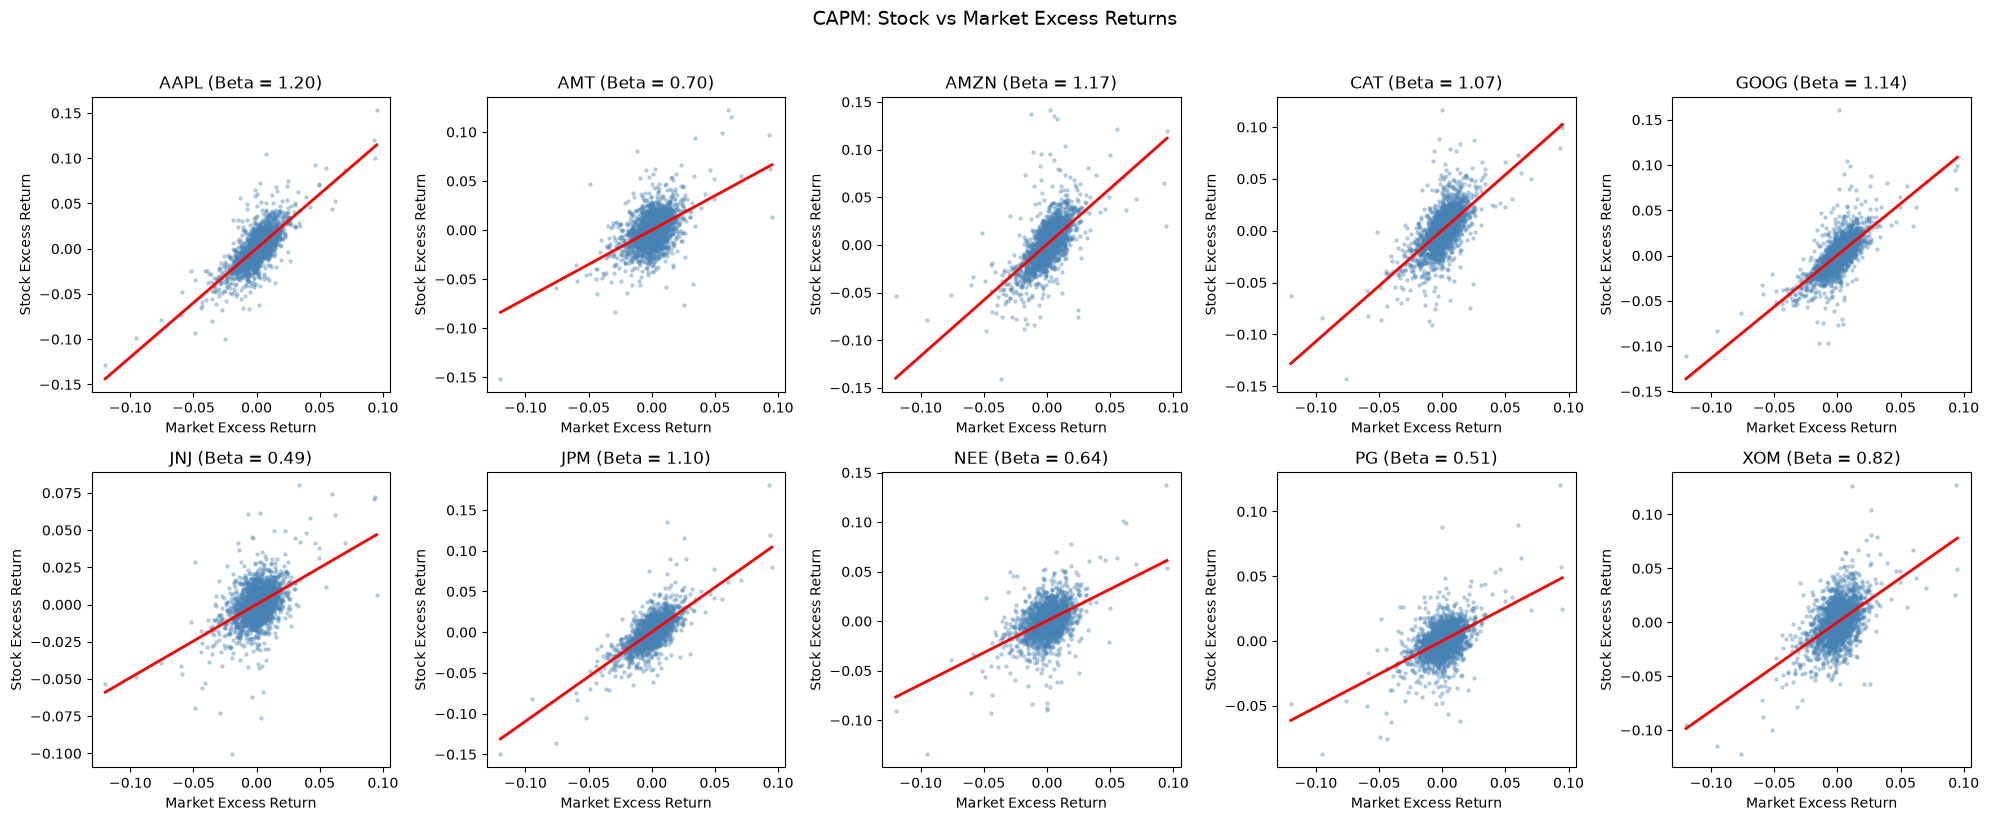

In [115]:
# Scatter Plot with Regression Line (All 10 Stocks)
fig, axes = plt.subplots(2,5,figsize=(20,8))
axes = axes.flatten()

for i, ticker in enumerate(excess_stock.columns):
    ax = axes[i]
    x = excess_market
    y = excess_stock[ticker]

    # Scatter plot
    ax.scatter(x,y,alpha=0.3, s=5, color='steelblue')

    # Regression line
    m = sm.OLS(y, sm.add_constant(x)).fit()
    x_line = np.linspace(x.min(), x.max(), 100)
    y_line = m.params['const'] + m.params['SPX'] * x_line
    ax.plot(x_line, y_line, color='red', linewidth=2)

    # Labels
    ax.set_title(f"{ticker} (Beta = {m.params['SPX']:.2f})")
    ax.set_xlabel('Market Excess Return')
    ax.set_ylabel('Stock Excess Return')

plt.suptitle('CAPM: Stock vs Market Excess Returns', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


- **Steep regression lines** (APPL, AMZN, GOOG, JPM, CAT) visually confirm high betas - these stocks move more than proportionally with the market.

- **Flat regression lines** (JNJ, PG, NEE) confirm low betas - market moves have a muted effect on these defensive names.

- **Scatter spread around the line** reflects idiosyncratic risk:
    - AMZN has the widest scatter - many large moves unexplained by the market (low R-square)
    - APPL and JPM have tighter clouds - more of their movement is market-driven (higher R-square)

- **Outlier points** far from the regression line represent extreme event days (e.g., earnings surprises, COVID crash) where stock-specific factors dominated.

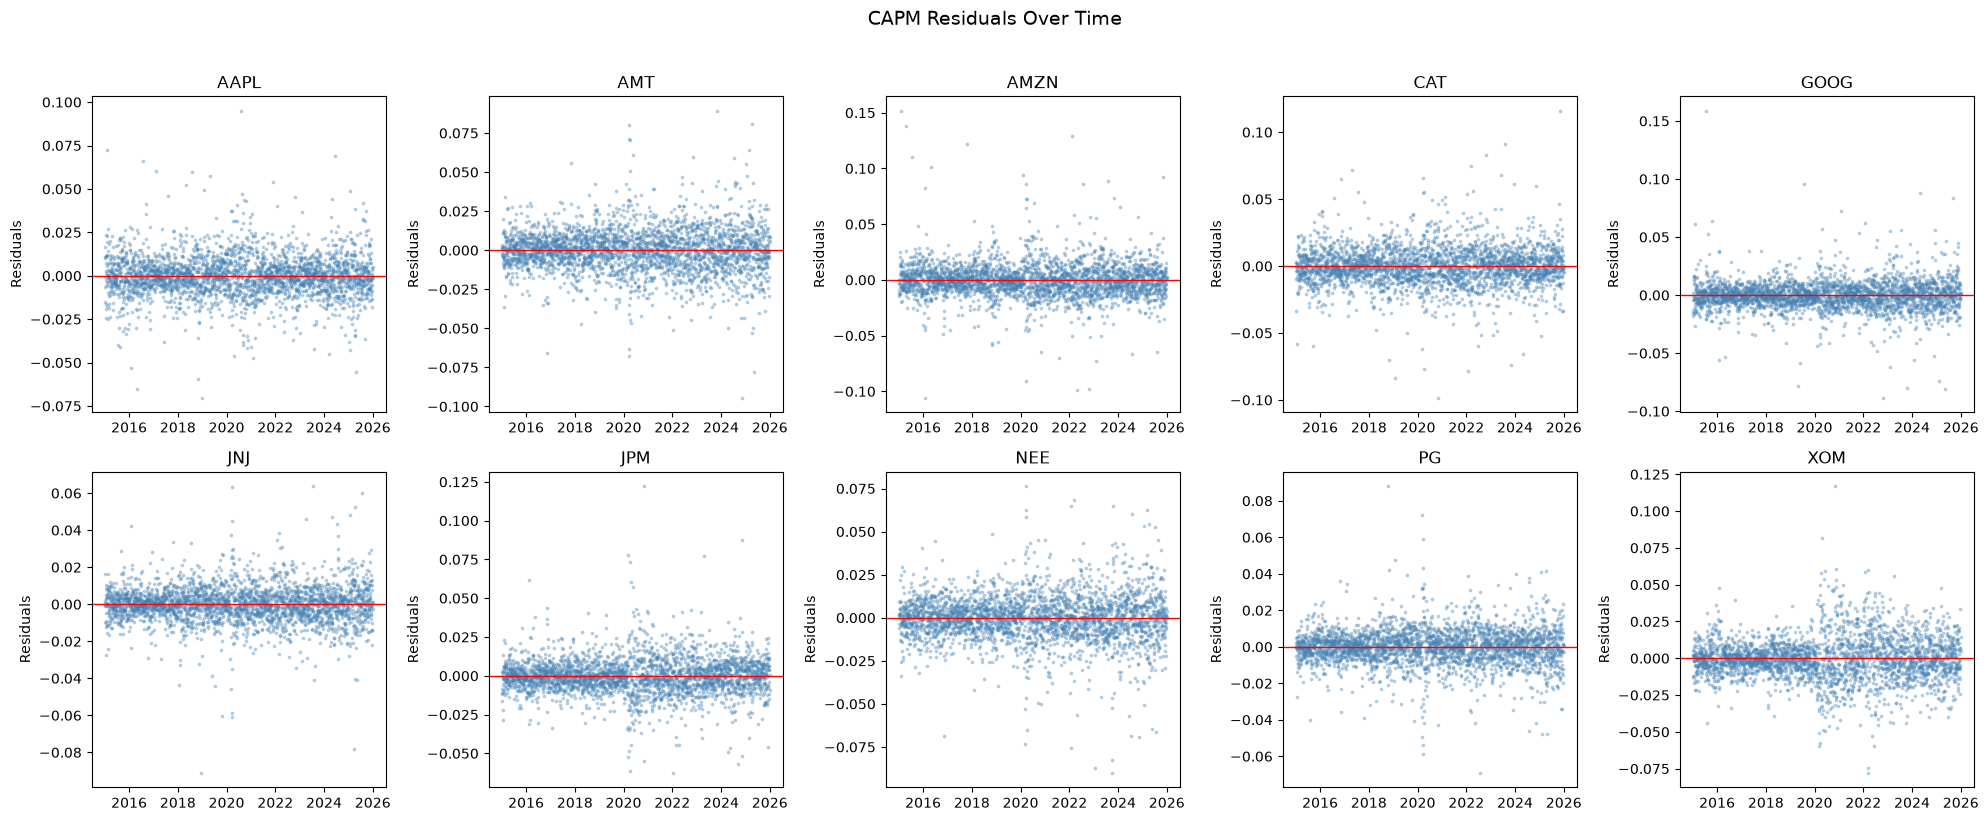

In [116]:
# Residual Plot
fig, axes = plt.subplots(2,5,figsize=(20,8))
axes = axes.flatten()

for i, ticker in enumerate(excess_stock.columns):
    y = excess_stock[ticker]
    model = sm.OLS(y, sm.add_constant(excess_market)).fit()
    residuals = model.resid

    ax = axes[i]
    ax.scatter(returns.index, residuals, alpha=0.3, s=3, color='steelblue')
    ax.axhline(y=0, color='red', linewidth=1)
    ax.set_title(ticker)
    ax.set_ylabel('Residuals')

plt.suptitle('CAPM Residuals Over Time', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

- **All reisuduals are centered at zero** - the regression is unbiased, with no systematic over- or under-prediction

    "- **Volatility clustering** is clearly visible: residual spread widens dramatically around March 2020 (COVID crash) for all 10 stocks, then gradually narrows. This means the variance of residuals is NOT constant over time - a violation of the homoscedasticity assumption (heteroscedasticity).\n",

- **AMZN** shows the most extreme outliers (rewsiduals reching +-15%), while **JNJ** and **PG** have the tighest residuals (+-6%).

- **Implication**: OLS coefficient estimates (alpha, beta) remain unbiased despite heteroscedasticity, but standard errors may be understated. In practice, Newey-West(HAC) robust standard errors would correct for this.


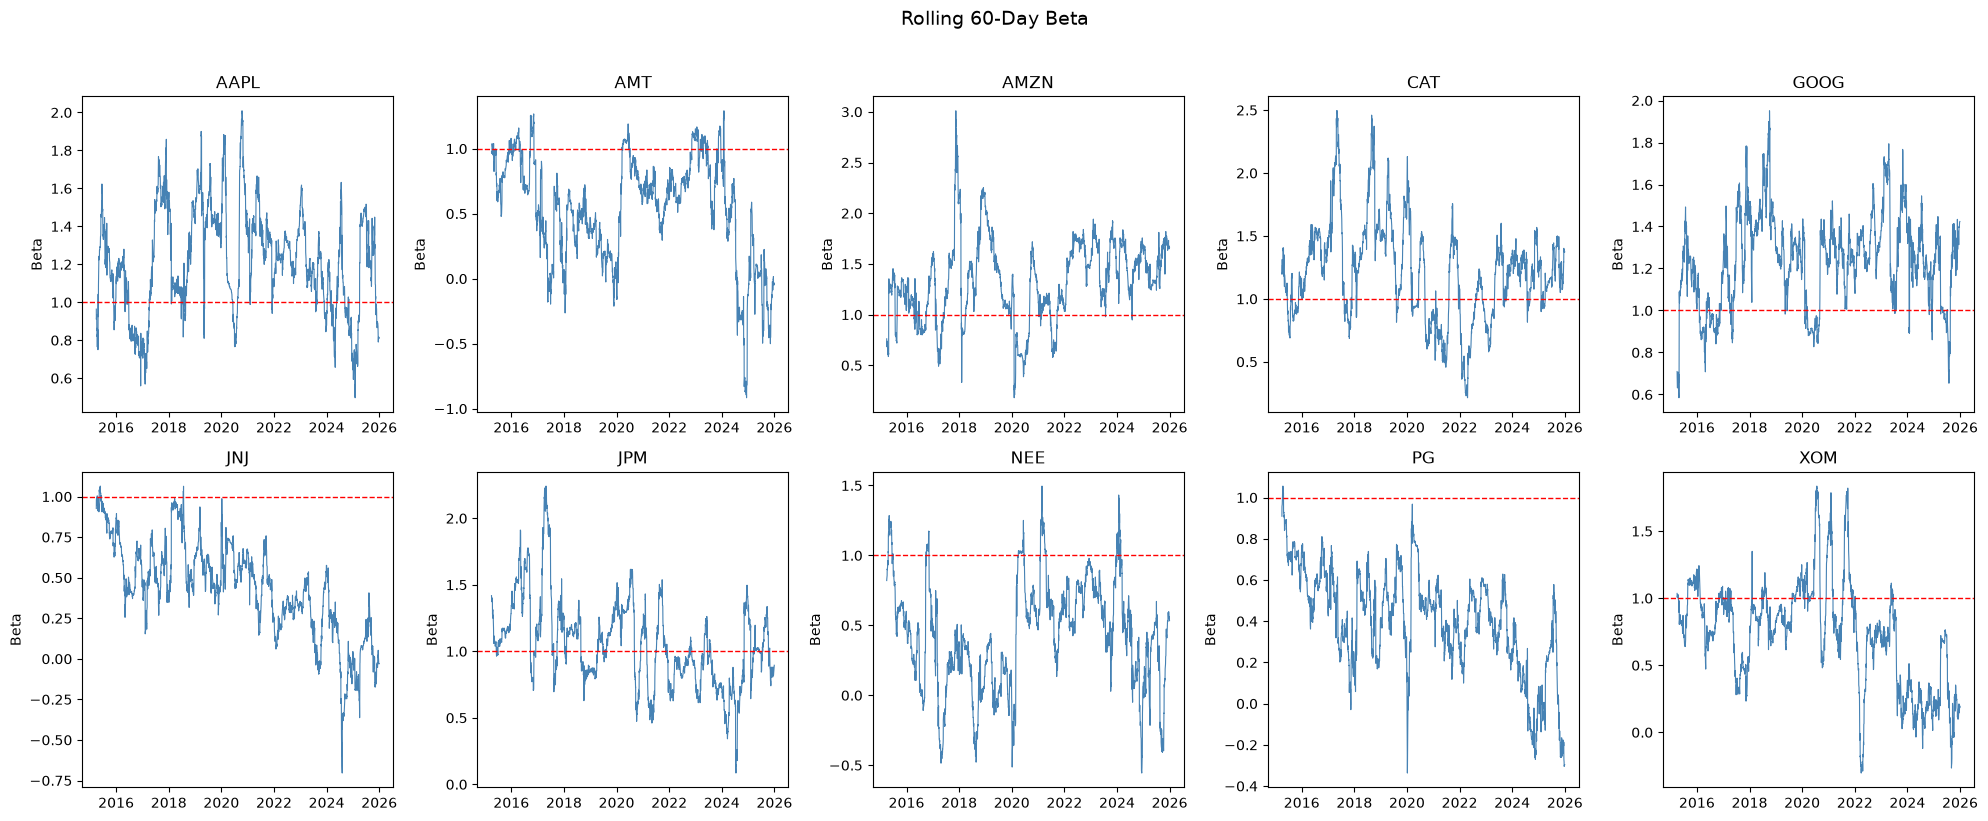

In [117]:
# Rolling Beta (60-day Window)
fig, axes = plt.subplots(2,5,figsize=(20,8))
axes = axes.flatten()
window = 60  # 60-day rolling window

for i, ticker in enumerate(excess_stock.columns):
    rolling_beta = []
    dates = []

    for t in range(window, len(excess_market)):
        y = excess_stock[ticker].iloc[t-window:t]
        x = sm.add_constant(excess_market.iloc[t-window:t])
        model = sm.OLS(y, x).fit()
        rolling_beta.append(model.params['SPX'])
        dates.append(excess_market.index[t])

    ax = axes[i]
    ax.plot(dates, rolling_beta, color='steelblue', linewidth = 0.8)
    ax.axhline(y=1, color='red', linestyle='--', linewidth=1)
    ax.set_title(ticker)
    ax.set_ylabel('Beta')

plt.suptitle('Rolling 60-Day Beta', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()



- **Beta is NOT constant** - every stock shows substantial time-variation, directly violating CAPM's assumption of a fixed beta.

- **Crisis behavior**: Betas spike during market stress (COVID crash in 2020). Coorelations tend toward 1 in a crash, amplifying beta estimates.

- **Notable patterns**:
    - JNJ's beta occasionally goes **negative** - during flight-to-safety episodes, investors sell equities and buy healthcare, causing JNJ to move opposite to the market.
    
    - AMZN has the most unstable beta (ranging from 0.5 to 3.0), reflecting its evolving business model from e-commerce to cloud infrasturcture.

    - APPL is relatively stable, staying between 0.6 and 2.0 - consistent market sensitivity.

    - JPM spikes above 2.0 during financial stress, then drops below 0.8 during calm periods - banks are the most regime-sensitive sector.

- **Implications**: A single historical beta may not be reliable for forward-looking risk management. This motivates conditional CAPM, DCC-GARCH models, or regime-switching approaches. 

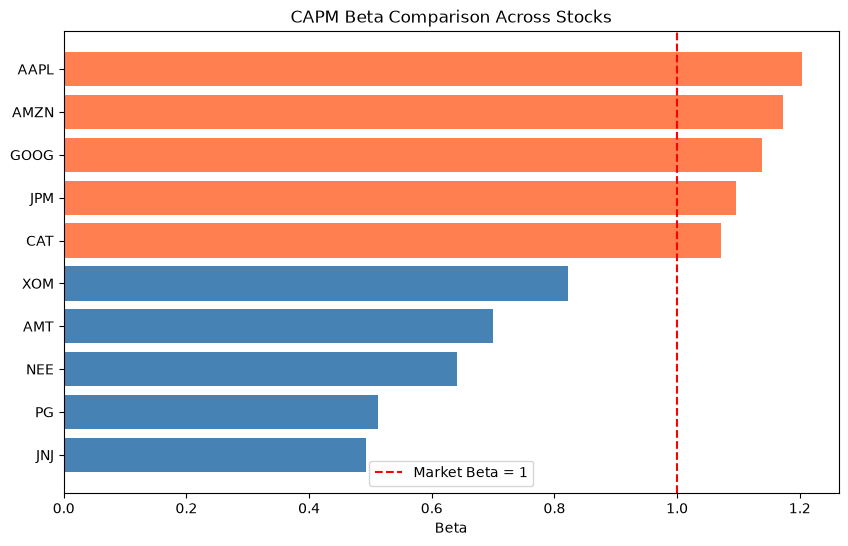

In [120]:
# Beta Comparison Bar Chart
betas = results_df['Beta'].sort_values(ascending=True)

plt.figure(figsize=(10,6))
colors = ['steelblue' if b<1 else 'coral' for b in betas]
plt.barh(betas.index, betas.values, color=colors)
plt.axvline(x=1, color='red', linestyle='--', label='Market Beta = 1')
plt.xlabel('Beta')
plt.title('CAPM Beta Comparison Across Stocks')
plt.legend()
plt.tight_layout
plt.show()

- The ranking clearly separates **defensitve sectors** (blue, beta<1) from **aggressive sectors** (coral, beta>1).'

- **JNJ (0.49)** and **PG(0.51)** at the bottom - healthcare and consumer staples with the least market sensitivity.

- **APPL(1.20)** at the top - technology with the highest market sensitibity.

- **XOM(0.82)** sits in the middle - energy has market exposure but also follows its own commodituy-rpice dynamics, partially decoupling it from equities. 

- The spread from 0.49 to 1.20 confirms that sector selection was effective at generating cross-sectional variation in beta.


In [121]:
# In-sample regression summary
summary_list = []

for ticker in excess_stock.columns:
    y = excess_stock[ticker]
    model = sm.OLS(y, X).fit()
    
    summary_list.append({
        'Stock': ticker,
        'Alpha': model.params['const'],
        'Alpha_tstat': model.tvalues['const'],
        'Alpha_pval': model.pvalues['const'],
        'Beta': model.params['SPX'],
        'Beta_tstat': model.tvalues['SPX'],
        'Beta_pval': model.pvalues['SPX'],
        'R-squared': model.rsquared,
        'F_stat': model.fvalue,
        'Durbin_Watson': sm.stats.stattools.durbin_watson(model.resid),
        'N_obs': int(model.nobs)
    })

summary_xdf = pd.DataFrame(summary_list).set_index('Stock')
summary_xdf = summary_xdf.round(4)
summary_xdf

,Alpha,Alpha_tstat,Alpha_pval,Beta,Beta_tstat,Beta_pval,R-squared,F_stat,Durbin_Watson,N_obs
Stock,,,,,,,,,,
AAPL,0.0005,1.9765,0.0482,1.2033,59.0484,0.0,0.5580,3486.7169,1.8616,2764
AMT,0.0001,0.2102,0.8335,0.7004,29.7820,0.0,0.2431,886.9691,1.9827,2764
AMZN,0.0006,2.0450,0.0410,1.1719,43.4673,0.0,0.4062,1889.4075,1.9692,2764
CAT,0.0004,1.4997,0.1338,1.0721,43.8482,0.0,0.4104,1922.6677,1.8969,2764
GOOG,0.0005,2.0765,0.0379,1.1391,52.6384,0.0,0.5008,2770.8063,1.9396,2764
JNJ,0.0001,0.7095,0.4781,0.4927,29.1279,0.0,0.2350,848.4355,2.0200,2764
JPM,0.0003,1.3532,0.1761,1.0961,55.0091,0.0,0.5228,3025.9998,2.0353,2764
NEE,0.0003,1.0456,0.2958,0.6415,27.6500,0.0,0.2168,764.5239,2.0145,2764
PG,0.0001,0.2645,0.7914,0.5124,29.9922,0.0,0.2457,899.5333,2.0200,2764


In [124]:
# Compare Results Across Different Time Windows                                                                                                           
periods = {                                                                                                                                               
    'Full (2015-2025)': ('2015-01-01', '2025-12-31'),
    'Pre-COVID (2015-2019)': ('2015-01-01', '2019-12-31'),
    'Post-COVID (2020-2025)': ('2020-01-01', '2025-12-31'),
}

comparison = []

for period_name, (start, end) in periods.items():
    mask = (returns.index >= start) & (returns.index <= end)
    sub_excess_stock = excess_stock.loc[mask]
    sub_excess_market = excess_market.loc[mask]
    X = sm.add_constant(sub_excess_market)

    for ticker in sub_excess_stock.columns:
        y = sub_excess_stock[ticker]
        model = sm.OLS(y, X).fit()
        comparison.append({
            'Period': period_name,
            'Ticker': ticker,
            'Alpha': model.params['const'],
            'Beta': model.params['SPX'],
            'N-obs': int(model.nobs),
        })

comparison_df = pd.DataFrame(comparison)
comparison_pivot = comparison_df.pivot(index='Ticker', columns='Period', values='Beta')
comparison_pivot = comparison_pivot.round(4)
print("=== Beta Comparison Across Different Time Windows ===")
print(comparison_pivot)

=== Beta Comparison Across Different Time Windows ===
Period  Full (2015-2025)  Post-COVID (2020-2025)  Pre-COVID (2015-2019)
Ticker                                                                 
AAPL              1.2033                  1.1908                 1.2398
AMT               0.7004                  0.7357                 0.5984
AMZN              1.1719                  1.1212                 1.3204
CAT               1.0721                  0.9830                 1.3309
GOOG              1.1391                  1.1201                 1.1941
JNJ               0.4927                  0.4250                 0.6896
JPM               1.0961                  1.0689                 1.1754
NEE               0.6415                  0.7453                 0.3402
PG                0.5124                  0.4942                 0.5657
XOM               0.8222                  0.7907                 0.9132


- **Stable betas**: APPL(1.24 -> 1.19), GOOG(1.19 -> 1.12), PG(0.57 -> 0.49) - these stocks maintained their risk profile across regimes.

- **Unstable betas**:
    - **NEE** nearly doubled (0.34 -> 0.75) - pre-COVID it was a low-volatility utility; post-COVID infrastructure spending stabilized its revenue.

    - **CAT** dropped from 1.33 to 0.98 - pre-COVID it was highly cyclical; post-COVID infrastructure spending stabilized its revenue. 

    - **JNJ** became more defensive (0.69 -> 0.43) - post-COVID, healthcare became an even stronger safe-haven sector.
    
    - **AMZN** dropped from 1.32 to 1.12 - as AWS and logistics matured, Amazon shifted from a volatile growth stock to more stable infrasturucture.

- **Conclustion**: Beta is regime-dependent. A full-period estimate blends strucuturally different market environments. potentially mischaracterizing a stock's current risk profile. 


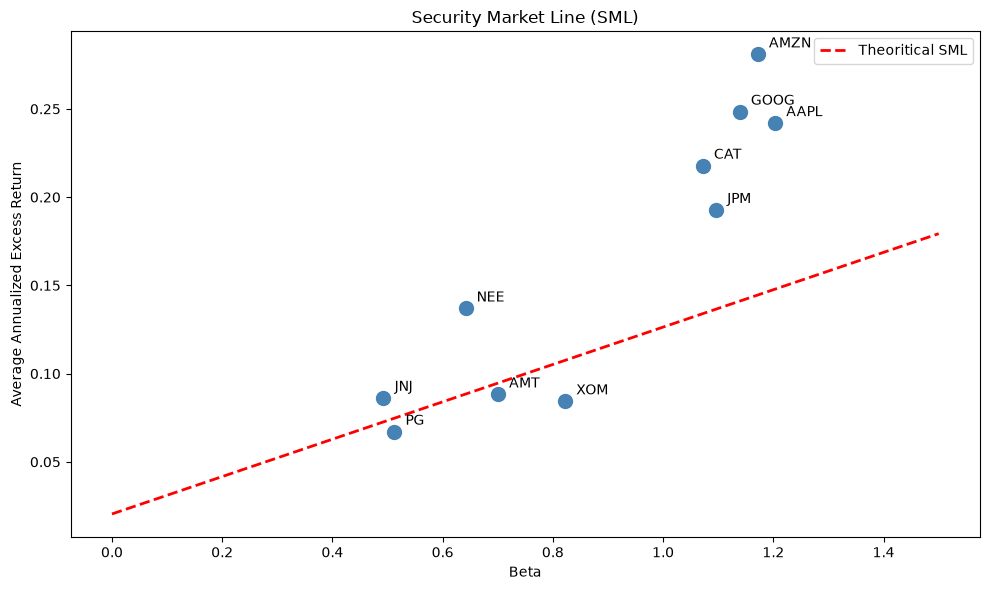

In [125]:
# Security Market Line (SML)
# Average annualized excess return for each stock
avg_excess_returns = excess_stock.mean() * 252

# Plot
plt.figure(figsize=(10,6))
plt.scatter(results_df['Beta'], avg_excess_returns, color='steelblue', s=100, zorder=5)

# Label each point with ticker name
for ticker in results_df.index:
    plt.annotate(ticker, (results_df.loc[ticker, 'Beta'], avg_excess_returns[ticker]), textcoords="offset points", xytext=(8,5), fontsize=10)

# Theortical SML: expectived return = risk-free + beta * market risk premium
rf_annual = rf_daily.mean() * 252
avg_market_excess = excess_market.mean() * 252
x_line = np.linspace(0, 1.5, 100)
y_line = rf_annual + x_line * avg_market_excess
plt.plot(x_line, y_line, color='red', linestyle='--', linewidth=2, label='Theoritical SML')

plt.xlabel('Beta')
plt.ylabel('Average Annualized Excess Return')
plt.title('Security Market Line (SML)')
plt.legend()
plt.tight_layout()
plt.show()




- **Most stocks plot aove the SML** - CAPM underpredicts returns for the majority of the sample, especially for high-beta growth stocks (AMZN, GOOG, APPL)

- **PG, AMT, and XOM sit near or slightly below the line** - CAPM accurately predicts returns for these defensive and value names. They earned roughly what their beta exposure justified, with no significant abnormal return.

- **The upward slope is correct** - higher-beta stocks generally earned higher returns, consistent with CAPM's directional prediction.

- **The relationship is not tight** - substantial scatter around the lin eindicates beta alone is an incomplete predictor of retunrs. AMZN and GOOG earned far more than their betas would predict, while XOM aearned less despite moderate beta.

- **Why most stocks are above the line**:
    - **Survivorship bias**: all 10 stocks are large-cap companies that survived and therived -failed companies are excluded.

    - **Bull market effect**: 2015-2025 was a historically strong period for U.S. equities.

- **The low-beta anomaly in reverse**: Interestingly, the high-beta stocks deviate MORE from the SML than low-beta stocks. CAPM predicts a linear relationship, but the actual pattern is steeper - high-beta stocks earned disproportionately more. This could reflect momentum or growth factor exposure unaccounted for by CAPM.

In [123]:
# Resample daily prices to monthly (last trading day of each month)
monthly_prices = prices.resample('ME').last()

# Compute monthly returns
monthly_returns = monthly_prices.pct_change().dropna()

# Monthly risk-free rate
monthly_returns = monthly_returns.loc[rf_monthly.index]

# Compute monthly excess returns
monthly_excess = monthly_returns.subtract(rf_monthly, axis=0)
monthly_excess_stock = monthly_excess.drop(columns='SPX')
monthly_excess_market = monthly_excess['SPX']

# Run CAPM regression on monthly data
X_m = sm.add_constant(monthly_excess_market)
monthly_results = {}

for ticker in monthly_excess_stock.columns:
    y = monthly_excess_stock[ticker]
    model = sm.OLS(y, X_m).fit()
    monthly_results[ticker] = {
        'Beta_Monthly': model.params['SPX'],
        'Alpha_pval_Monthly': model.pvalues['const'],
        'R_sq_Monthly': model.rsquared
    }

monthly_df = pd.DataFrame(monthly_results).T

# Compare daily vs monthly betas side by side
compare = pd.DataFrame({
    'Beta_Daily': results_df['Beta'],
    'Beta_Monthly': monthly_df['Beta_Monthly'],
    'Diff': monthly_df['Beta_Monthly'] - results_df['Beta'],
    'R_sq_Daily': results_df['R-squared'],  # Changed: was 'R_sq', now 'R-squared'
    'R_sq_Monthly': monthly_df['R_sq_Monthly']
}).round(4)

print("=============== Daily vs Monthly Beta Comparison ===============")
print(compare)

=============== Daily vs Monthly Beta Comparison ===============
      Beta_Daily  Beta_Monthly    Diff  R_sq_Daily  R_sq_Monthly
AAPL      1.2033        1.2071  0.0038      0.5580        0.4405
AMT       0.7004        0.6273 -0.0731      0.2431        0.1787
AMZN      1.1719        1.3068  0.1349      0.4062        0.4142
CAT       1.0721        1.2733  0.2012      0.4104        0.4099
GOOG      1.1391        1.0442 -0.0949      0.5008        0.3912
JNJ       0.4927        0.5460  0.0533      0.2350        0.2571
JPM       1.0961        1.1457  0.0496      0.5228        0.5193
NEE       0.6415        0.4534 -0.1881      0.2168        0.1067
PG        0.5124        0.4070 -0.1054      0.2457        0.1469
XOM       0.8222        0.8867  0.0645      0.2884        0.2514


- **Beta rankings are preserved** - defensive stocks remian low-beta and aggressive stocks remain high-beta regardless of data frequency. The qualitative conclustions are robust.

- **Exact values shift**:
    - CAT: biggest change (1.07 daily -> 1.27 monthly) - monthly data captures the full cycplical swing that daily noise partially masks.

    - NEE: 0.64 daily -> 0.45 monthly - daily noise inflated NEE's beta

    - PG: 0.51 daily -> 0.41 monethly - even more defensive at the monthly horizon.

- **R-squared drops for all stocks with monthly data** - fewer observations (120 vs 2764) means less statistical power, and each moneth carries more weight. 

- **Conclusion**: Results are qualitatively robust to data frequency. The choice between daily and monthly affects precision of estimates but does not change the economic interpretation. 


## Conclusion

### 1. Which stocks have beta above or below 1?
Five stocks have beta above 1 (aggressive): AAPL(1.20), AMZN(1.17), GOOG(1.14), JPM(1.10), and CAT(1.07). These are all from cyclical or growth sectors - technology, financials, and industrials - where revenue is sensitive to economic conditions. Five stocks have beta below 1 (defensive): XOM (0.82), AMT(0.70), NEE(0.64), PG(0.51), and JNJ(0.49). These are from sectors with stable, inelastic demand - energy, real estate, utilities, consumer staples, and healthcare.

### 2. Are defensive stocks actually lower beta?
Yes. The three lowest-beta stock are JNJ(0.49), PG(0.51), and NEE(0.64) - healthcare, consumer staples, and utilities. These sectors have revenues that are largely independent of the business cycle. People buy medicine, toothpaste, and electricity in recessions. This confirms CAPM's prediction that stocks with less economic sensitivity carry less systematic risk.

### 3. Which stocks have statistically significant alpha?
Three stocks have alpha significant at the 5% level: APPL(p=0.048), AMZN(p=0.041), and GOOG(p=0.038). All three are tech and growth stocks, suggesting CAPM is incomplete for companies with strong growth, momentum, or innovation characteristics. The remaining 7 stocks have alpha statistically indistinguishable from zero - CAPM holds for these names. The significant alphas likely reflect exposure to risk factors that CAPM omits (size, value, momentum) rather than genuine mispricing, which motivates multi-factor models like Fama-French.

### 4. Does beta change during crises?
Yes, substantially. Rolling 60-day beta analysis reveals that betas spike during market stress - most stocks showed elevated betas during the COVID crash (March 2020) as coorelations increased. JNJ's beta occasionally went negative during flight-to-safety episodes. Sub-period analysis confirms this: NEE's beta nearly doubled from pre-COVID (0.34) to post-COVID (0.75) due to the renewables growth narrati8ve, while JNJ became more defensive (0.69 -> 0.43). AMZN's beta swung from 0.5 to 3.0 across the sample. This time-variation directly violates CAPM's assumption of constant beta.

### 5. Are residuals normally distributed?
No. The Jarque-Bera test rejects normality for all 10 stocks. APPL, for example, has kurtosis of 8.43 (normal=3). indicating fat tails - extreme daily moves occur far more frequently that a Gaussian distribution predicts. Residual plots alos show volatility clustering, with variance spiking during crisis approximate. Newey-West robust standard errors would provide more rigorous inference.

### 6. Does daily vs monthly data change conlcustions?
The qualitative conlsutions are robust - beta rankings are preserved across both frequencies. Defensive stocks remain low-beta and aggressive stocks decreases across the board with monethly data due to fewer observations (120 vs 2764). The choice of data frequency affects the precision of estimates but doews not change the economic interpretation. 

### Overall
CAPM correctly identifies the direction of the risk-return tradeoff and produces economically intuitive beta rankings across sectors. However, it fails on three fronts: (1) significant alpha for growth stocks that CAPM cannot explain, (2) time-varying betas that violate the static model assumption, and (3) non-normal residuals with fat tails. These limitations motivate extensions including Fama-French multi-factor models, conditional CAPM with macroeconomic state variables, and robust estimation methods such as Newey-West standard errors.

In [130]:
# Save all charts to outputs/ folder                                                                                                                      
                
# Scatter plots
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()
for i, ticker in enumerate(excess_stock.columns):
    ax = axes[i]
    x = excess_market
    y = excess_stock[ticker]
    ax.scatter(x, y, alpha=0.3, s=5, color='steelblue')
    m = sm.OLS(y, sm.add_constant(x)).fit()
    x_line = np.linspace(x.min(), x.max(), 100)
    y_line = m.params['const'] + m.params['SPX'] * x_line
    ax.plot(x_line, y_line, color='red', linewidth=2)
    ax.set_title(f"{ticker} (Beta = {m.params['SPX']:.2f})")
    ax.set_xlabel('Market Excess Return')
    ax.set_ylabel('Stock Excess Return')
plt.suptitle('CAPM: Stock vs Market Excess Returns', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('../outputs/scatter_plots.png', dpi=300, bbox_inches='tight')
plt.close()

# Residual plots
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()
for i, ticker in enumerate(excess_stock.columns):
    y = excess_stock[ticker]
    model = sm.OLS(y, sm.add_constant(excess_market)).fit()
    residuals = model.resid
    ax = axes[i]
    ax.scatter(returns.index, residuals, alpha=0.3, s=3, color='steelblue')
    ax.axhline(y=0, color='red', linewidth=1)
    ax.set_title(ticker)
    ax.set_ylabel('Residuals')
plt.suptitle('CAPM Residuals Over Time', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('../outputs/residual_plots.png', dpi=300, bbox_inches='tight')
plt.close()

# Rolling beta
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()
window = 60
for i, ticker in enumerate(excess_stock.columns):
    rolling_beta = []
    dates = []
    for t in range(window, len(excess_market)):
        y = excess_stock[ticker].iloc[t-window:t]
        x = sm.add_constant(excess_market.iloc[t-window:t])
        model = sm.OLS(y, x).fit()
        rolling_beta.append(model.params['SPX'])
        dates.append(excess_market.index[t])
    ax = axes[i]
    ax.plot(dates, rolling_beta, color='steelblue', linewidth=0.8)
    ax.axhline(y=1, color='red', linestyle='--', linewidth=1)
    ax.set_title(ticker)
    ax.set_ylabel('Beta')
plt.suptitle('Rolling 60-Day Beta', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('../outputs/rolling_beta.png', dpi=300, bbox_inches='tight')
plt.close()

# Beta bar chart
betas = results_df['Beta'].sort_values(ascending=True)
plt.figure(figsize=(10, 6))
colors = ['steelblue' if b < 1 else 'coral' for b in betas]
plt.barh(betas.index, betas.values, color=colors)
plt.axvline(x=1, color='red', linestyle='--', linewidth=1, label='Beta = 1 (Market)')
plt.xlabel('Beta')
plt.title('CAPM Beta Comparison Across Stocks')
plt.legend()
plt.tight_layout()
plt.savefig('../outputs/beta_comparison.png', dpi=300, bbox_inches='tight')
plt.close()

# SML
avg_excess_returns = excess_stock.mean() * 252
plt.figure(figsize=(10, 6))
plt.scatter(results_df['Beta'], avg_excess_returns, color='steelblue', s=100, zorder=5)
for ticker in results_df.index:
    plt.annotate(ticker, (results_df.loc[ticker, 'Beta'], avg_excess_returns[ticker]),
                textcoords='offset points', xytext=(8, 5), fontsize=10)
rf_annual = rf_daily.mean() * 252
avg_market_excess = excess_market.mean() * 252
x_line = np.linspace(0, 1.5, 100)
y_line = rf_annual + x_line * avg_market_excess
plt.plot(x_line, y_line, color='red', linestyle='--', linewidth=2, label='Theoretical SML')
plt.xlabel('Beta')
plt.ylabel('Annualized Excess Return')
plt.title('Security Market Line (SML)')
plt.legend()
plt.tight_layout()
plt.savefig('../outputs/sml.png', dpi=300, bbox_inches='tight')
plt.close()

print("All charts saved to outputs/ folder")

All charts saved to outputs/ folder


In [131]:
# Save result tables to outputs/ folder
results_df.to_csv('../outputs/capm_results.csv')
summary_xdf.to_csv('../outputs/regression_summary.csv')
compare.to_csv('../outputs/daily_vs_monthly.csv')
comparison_pivot.to_csv('../outputs/time_window_comparison.csv')

print("All tables saved to outputs/ folder")

All tables saved to outputs/ folder
